# Part 3: Full-Data Model Comparison

This section expands upon Part 2 by utilizing the full training dataset (64,069 rows). Our primary objectives are to investigate how increasing the amount of labeled data impacts model performance and to assess our models' proximity to the published state-of-the-art for this 7-class classification task. We achieve this by fine-tuning `bert-base-uncased` on progressively larger fractions of the data and visualizing the results as a learning curve.

## Table of Contents

* [Overview of Study Structure](#Overview-of-Study-Structure)
* [Setup and Environment](#Setup-and-Environment)
* [3a. Full Dataset Training](#3a.-Full-Dataset-Training)
* [3b. Learning Curve Analysis](#3b.-Learning-Curve-Analysis)
* [3c. Technique Comparison](#3c.-Technique-Comparison)
* [3d. Methodology Analysis](#3d.-Methodology-Analysis)
* [Teacher Model Selection for Part 4](#Teacher-Model-Selection-for-Part-4-(Validation-Based))
* [Summary and Conclusion](#Summary-and-Conclusion)

## Project Structure Overview

To ensure a fair comparison, the training (3 epochs, batch size 32, learning rate 2e-5) remains constant across all data fractions. This approach allows us to isolate the effect of data quantity on model performance. Training is conducted on Colab, and scoring is performed locally against the predefined test set.

## Setup and Environment

These initial cells configure the environment, load the required libraries, and set up our paths and project configurations.

Shared helper functions live in `src/` (data, evaluation, plotting) and are documented in the project README.

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q datasets==4.8.5
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Local run detected - no Colab setup needed.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Standard library imports
import hashlib
import json
import math
import random
import sys
import tempfile
from pathlib import Path

# Third-party libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


def _find_project_root(start):
    """Return the folder that contains data/processed. Walk up from `start` for local runs,
    then fall back to the Colab Drive locations (with or without the Final_submission folder)."""
    candidates = [start, *start.parents,
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT/Final_submission'),
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT')]
    for d in candidates:
        if (d / 'data' / 'processed').exists():
            return d
    raise FileNotFoundError(
        'Project root not found (no folder with data/processed). On Colab, mount Drive first '
        'and point this at the folder that holds src/, data/, and config/.')

# Determine project root and add to path
PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))

# Import custom utility functions
from src.utils.notebook_setup import bootstrap
from src.utils.evaluation import make_evaluate_model
from src.utils.guards import run_split_guard
from src.utils.metrics import evaluate_predictions, mcnemar_test
from src.utils.visualization import (
    plot_part3_learning_curve, plot_part3_synth_vs_distill_recall,
)

# Load project configurations via bootstrap
S = bootstrap(PROJECT_ROOT)
_CFG = S.cfg
_p3 = _CFG['part3']
_bert = _p3['bert']
save_fig = S.save_fig

# Seed and environment setup
SEED = S.SEED
CANONICAL_SEED = _CFG['canonical_seed']
IN_COLAB, RUN_TRAINING = S.IN_COLAB, S.RUN_TRAINING

# Extract BERT training hyperparameters
MODEL_NAME = _bert['model_name']
MAX_LENGTH = _bert['max_length']
TRAIN_BATCH = _bert['train_batch']
EVAL_BATCH = _bert['eval_batch']
LR = _bert['lr']
EPOCHS = _bert['epochs']
WARMUP_FRAC = _bert['warmup_frac']
WEIGHT_DECAY = _bert['weight_decay']
LOGGING_STEPS = _bert['logging_steps']
MAX_FINAL_TRAIN_LOSS = _bert['max_final_train_loss']
DATASET_REVISION = _CFG['dataset']['revision']
VAL_SANITY_N = _CFG['eval']['val_sanity_n']
N_BOOT = _CFG['eval']['n_boot']

FRACTIONS = tuple(_p3['fractions'])
SEEDS = list(_p3['part4_seeds'])

# Helper functions for run names
def pct_run_name(pct):
    return f'part3_bert_pct{pct}'


def staged_name(pct):
    return f'{pct_run_name(pct)}_seed{CANONICAL_SEED}'


PCT100_CKPT_NAME = f'{pct_run_name(100)}_model'

# Set up paths and directories
DATA_DIR, RESULTS_DIR, METRICS_DIR, PRED_DIR, FIG_DIR, RAW_PRED_DIR = (
    S.DATA_DIR, S.RESULTS_DIR, S.METRICS_DIR, S.PRED_DIR, S.FIG_DIR, S.RAW_PRED_DIR)
CKPT_DIR = Path('/content/part3_ckpt') if IN_COLAB else Path(tempfile.gettempdir()) / 'part3_ckpt'
FRACTIONS_MANIFEST = DATA_DIR / 'part3_fractions_manifest.json'

# Import heavy GPU libraries if running in Colab/Training mode
if RUN_TRAINING:
    import accelerate
    import torch
    import transformers
    from datasets import Dataset
    from transformers import (
        AutoModelForSequenceClassification, AutoTokenizer,
        DataCollatorWithPadding, Trainer, TrainingArguments, set_seed
    )

In [ ]:
from src.utils.guards import run_split_guard

guard = run_split_guard(DATA_DIR, expected_revision=_CFG['dataset']['revision'])
labels, classes, splits = guard['labels'], guard['classes'], guard['splits']
test_df, y_test, manifest = guard['test_df'], guard['y_test'], guard['manifest']
train_df_full = splits['train']

Split guard OK - test fingerprint 0da3f09e8a2b... matches the manifest.
Frozen splits: 64,069 train / 16,018 val / 20,022 test  -  dataset revision 186902250e94...


### 3a. Full Dataset Training

#### Data Fraction Definition

To accurately measure the effect of dataset size, we need to create nested subsets (1%, 10%, 25%, 50%, 75%, and 100%). The following cells draw these fractions and freeze them securely using a manifest to guarantee reproducibility.

In [ ]:
if FRACTIONS_MANIFEST.exists():
    print(f'{FRACTIONS_MANIFEST.name} already exists - the draw is frozen. Nothing to do.')
else:
    rng = np.random.default_rng(SEED)
    class_order = {}
    for label in classes:
        ids = train_df_full.index[train_df_full['status'] == label].to_numpy()
        class_order[label] = ids[rng.permutation(len(ids))]

    per_fraction = {}
    prev_ids = set()
    for pct in FRACTIONS:
        ids = []
        for label in classes:
            n_cls = len(class_order[label])
            take = n_cls if pct == 100 else int(round(n_cls * pct / 100))
            ids.extend(int(i) for i in class_order[label][:take])

        ids = sorted(ids)
        assert prev_ids <= set(ids), f'nesting violated at {pct}%'
        prev_ids = set(ids)

        sub = train_df_full.loc[ids]
        per_fraction[str(pct)] = {
            'n': len(ids),
            'ids_sha256': hashlib.sha256(','.join(map(str, ids)).encode()).hexdigest(),
            'per_class': {k: int(v) for k, v in sub['status'].value_counts().items()},
            'selected_ids': ids,
        }

    assert per_fraction['100']['n'] == len(train_df_full), '100% must be all of train.parquet'

    train_ids_sorted = sorted(int(i) for i in train_df_full.index)
    manifest = {
        'seed': SEED,
        'fractions': list(FRACTIONS),
        'nested': True,
        'source': {
            'file': 'train.parquet',
            'split_seed': 42,
            'dataset_revision': DATASET_REVISION,
            'train_ids_sha256': hashlib.sha256(','.join(map(str, train_ids_sorted)).encode()).hexdigest(),
        },
        'per_fraction': per_fraction,
    }

    FRACTIONS_MANIFEST.write_text(json.dumps(manifest, indent=2))
    print(f'Frozen {FRACTIONS_MANIFEST.name}:')
    for pct in FRACTIONS:
        f = per_fraction[str(pct)]
        print(f"  {pct:>3}% - {f['n']:>6,} rows  ids {f['ids_sha256'][:12]}...")


part3_fractions_manifest.json already exists - the draw is frozen. Nothing to do.


In [ ]:
if not FRACTIONS_MANIFEST.exists():
    raise FileNotFoundError(f'{FRACTIONS_MANIFEST.name} missing from {DATA_DIR}')

frac_manifest = json.loads(FRACTIONS_MANIFEST.read_text())
assert frac_manifest['seed'] == SEED, 'manifest seed differs from SEED'
assert [int(p) for p in frac_manifest['fractions']] == list(FRACTIONS), 'manifest fractions differ from FRACTIONS'

train_ids_sorted = sorted(int(i) for i in train_df_full.index)
assert hashlib.sha256(','.join(map(str, train_ids_sorted)).encode()).hexdigest() == frac_manifest['source']['train_ids_sha256'], \
    'train.parquet does NOT match the source fingerprint in the fractions manifest'

fraction_dfs = {}
prev_ids = set()
train_id_set = set(train_ids_sorted)
for pct in FRACTIONS:
    f = frac_manifest['per_fraction'][str(pct)]
    ids = [int(i) for i in f['selected_ids']]
    recomputed = hashlib.sha256(','.join(map(str, sorted(ids))).encode()).hexdigest()
    assert recomputed == f['ids_sha256'], f'{pct}% ids do not match their manifest fingerprint'
    assert len(ids) == len(set(ids)) == f['n'], f'{pct}% id list has duplicates or a wrong n'
    assert set(ids) <= train_id_set, f'{pct}% contains ids outside train.parquet'
    assert prev_ids <= set(ids), f'nesting violated at {pct}%'
    prev_ids = set(ids)
    sub = train_df_full.loc[ids]
    assert {k: int(v) for k, v in sub['status'].value_counts().items()} == f['per_class'], \
        f'{pct}% per-class counts no longer match the manifest'
    fraction_dfs[pct] = sub

assert len(fraction_dfs[100]) == len(train_df_full), 'the 100% fraction must be all of train.parquet'

print('Fraction guard OK - all subsets rebuilt and fingerprint-verified:')
for pct in FRACTIONS:
    print(f'  {pct:>3}% - {len(fraction_dfs[pct]):>6,} rows  ids {frac_manifest["per_fraction"][str(pct)]["ids_sha256"][:12]}...')


Fraction guard OK - all subsets rebuilt and fingerprint-verified:
    1% -    641 rows  ids 8fc3de0408d1...
   10% -  6,407 rows  ids ccc7f0ee3cd9...
   25% - 16,018 rows  ids c85cbc79d6c0...
   50% - 32,035 rows  ids 66893a5ee6d7...
   75% - 48,051 rows  ids e988d7c07c01...
  100% - 64,069 rows  ids 74647be27766...


#### Text Tokenization

Before feeding the textual data into BERT, we must tokenize it. This step converts the raw text into integer token IDs and handles padding and truncation.

In [ ]:
if RUN_TRAINING:
    label2id, id2label = labels['label2id'], labels['id2label']
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def tokenize_frame(frame, with_labels):
        ds = Dataset.from_pandas(frame.reset_index(drop=True))
        if with_labels:
            ds = ds.map(lambda batch: {'labels': [label2id[s] for s in batch['status']]}, batched=True)
        ds = ds.map(lambda batch: tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH),
                    batched=True, remove_columns=[c for c in ('text', 'status') if c in ds.column_names])
        return ds

    test_ds = tokenize_frame(test_df, with_labels=False)
    val_sanity_df = splits['val'].sample(n=VAL_SANITY_N, random_state=SEED)
    val_sanity_ds = tokenize_frame(val_sanity_df, with_labels=False)
    print(f'Tokenized: test {len(test_ds):,} rows, val sanity {len(val_sanity_ds):,} rows.')


Map:   0%|          | 0/20022 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenized: test 20,022 rows, val sanity 1,000 rows.


In [ ]:
def train_and_predict_full(train_df, run_name, seed, save_checkpoint_as=None, eval_df=None, eval_index_name='test_id'):
    set_seed(seed)
    torch.manual_seed(seed)

    steps_per_epoch = math.ceil(len(train_df) / TRAIN_BATCH)
    total_steps = steps_per_epoch * EPOCHS
    warmup_steps = max(1, int(total_steps * WARMUP_FRAC))
    print(f'{run_name}: {len(train_df):,} rows -> {total_steps:,} optimizer steps ({warmup_steps} warmup)')

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(classes), id2label=id2label, label2id=label2id)

    args = TrainingArguments(
        output_dir=str(CKPT_DIR / run_name),
        seed=seed,
        data_seed=seed,
        learning_rate=LR,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH,
        per_device_eval_batch_size=EVAL_BATCH,
        warmup_steps=warmup_steps,
        weight_decay=WEIGHT_DECAY,
        fp16=torch.cuda.is_available(),
        eval_strategy='no',
        save_strategy='no',
        logging_steps=LOGGING_STEPS,
        report_to='none',
    )
    trainer = Trainer(model=model, args=args,
                      train_dataset=tokenize_frame(train_df, with_labels=True),
                      processing_class=tokenizer,
                      data_collator=DataCollatorWithPadding(tokenizer=tokenizer))
    trainer.train()

    def predict_ids(trainer, ds):
        logits = trainer.predict(ds).predictions
        if isinstance(logits, tuple):
            logits = logits[0]
        return np.argmax(logits, axis=-1)

    train_losses = [h['loss'] for h in trainer.state.log_history if 'loss' in h]
    final_loss = train_losses[-1] if train_losses else float('nan')
    print(f'{run_name}: final train loss {final_loss:.4f}')

    val_spread = len(set(predict_ids(trainer, val_sanity_ds)))
    print(f'{run_name}: {val_spread}/{len(classes)} classes predicted on the val sanity sample')

    _eval_ds = test_ds if eval_df is None else tokenize_frame(eval_df, with_labels=False)
    _eval_index = test_df.index if eval_df is None else eval_df.index
    y_pred = [id2label[int(i)] for i in predict_ids(trainer, _eval_ds)]

    csv_path = RAW_PRED_DIR / f'{run_name}.csv'
    pd.DataFrame({'y_pred': y_pred}, index=_eval_index).rename_axis(eval_index_name).to_csv(csv_path)

    if save_checkpoint_as:
        model_dir = RAW_PRED_DIR / save_checkpoint_as
        trainer.save_model(str(model_dir))
        tokenizer.save_pretrained(str(model_dir))
        (model_dir / 'training_args.json').write_text(json.dumps(args.to_dict(), indent=2, default=str))
        print(f'{run_name}: final model + training config saved to {model_dir}')

    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    summary = {'run_name': run_name, 'seed': seed,
               'n_train_rows': int(len(train_df)),
               'total_steps': int(total_steps), 'warmup_steps': int(warmup_steps),
               'final_loss': float(final_loss),
               'loss_history': train_losses,
               'val_class_spread': int(val_spread),
               'torch': torch.__version__, 'transformers': transformers.__version__,
               'accelerate': accelerate.__version__, 'csv_path': str(csv_path)}
    (RAW_PRED_DIR / f'{run_name}.json').write_text(json.dumps(summary, indent=2))
    return summary

In [ ]:
if RUN_TRAINING:
    todo = [p for p in FRACTIONS if not (RAW_PRED_DIR / f'{staged_name(p)}.csv').exists()]
    done = [p for p in FRACTIONS if p not in todo]
    if done:
        print(f'Already staged, skipping fractions {done}')

    summaries = [train_and_predict_full(fraction_dfs[pct], staged_name(pct), CANONICAL_SEED,
                                        save_checkpoint_as=PCT100_CKPT_NAME if pct == 100 else None)
                 for pct in todo]
    if summaries:
        print(pd.DataFrame(summaries).drop(columns='loss_history').to_string(index=False))
else:
    print('RUN_TRAINING is False - the 3a fractions train on Colab. Skipping.')


Already staged, skipping fractions [1, 10, 25, 50, 75, 100]


In [ ]:
evaluate_model = make_evaluate_model(test_df=test_df, y_test=y_test, classes=classes, fig_dir=FIG_DIR, n_boot=N_BOOT, seed=SEED)
rows = []
missing_any = False
for pct in FRACTIONS:
    path = RAW_PRED_DIR / f'{staged_name(pct)}.csv'
    if not path.exists():
        print(f'Skipping scoring for {pct}%: Raw prediction CSV {path.name} is missing.')
        missing_any = True
        continue

    sidecar = path.with_suffix('.json')
    run = json.loads(sidecar.read_text()) if sidecar.exists() else None
    if run is None:
        print(f'WARNING: {sidecar.name} missing - no sanity/version record for {pct}%.')
    else:
        if not run['final_loss'] < MAX_FINAL_TRAIN_LOSS:
            print(f"WARNING: {pct}% final train loss {run['final_loss']} >= {MAX_FINAL_TRAIN_LOSS} - likely a silent failure.")
        if run['val_class_spread'] < len(classes):
            print(f"WARNING: {pct}% predicted only {run['val_class_spread']}/{len(classes)} classes on the val sanity sample.")

    preds = pd.read_csv(path, index_col='test_id')
    assert preds.index.equals(test_df.index), f'{path.name} is not aligned with the frozen test index.'

    f = frac_manifest['per_fraction'][str(pct)]
    m = evaluate_model(
        pct_run_name(pct), preds['y_pred'].to_numpy(),
        title=None,
        make_figure=False,
        extras={'n_train_labels': f['n'],
                'fraction_pct': pct,
                'fraction_ids_sha256': f['ids_sha256'],
                'recipe': {'epochs': EPOCHS, 'train_batch': TRAIN_BATCH, 'lr': LR, 'warmup_frac': WARMUP_FRAC, 'max_length': MAX_LENGTH},
                'canonical_seed': CANONICAL_SEED,
                'single_seed_disclosed': True,
                'seed_runs': {str(CANONICAL_SEED): run} if run else {}}
    )
    rows.append({'pct': pct, 'n': f['n'], 'accuracy': m['accuracy'],
                 'macro_f1': m['macro_f1'], 'kappa': m['kappa'],
                 'suicidal_recall': m['per_class']['suicidal']['recall']})
    print()

if rows:
    print(pd.DataFrame(rows).set_index('pct').round(4).to_string())
    print('\nNow re-run notebooks/00_evaluation.ipynb top to bottom to refresh the ladder.')
elif missing_any:
    print(f'Missing CSVs in {RAW_PRED_DIR}. Ensure training is complete.')
else:
    print(f'No CSVs found in {RAW_PRED_DIR}. Run training first.')

part3_bert_pct1
Accuracy: 0.6118  (95% CI 0.6051-0.6181)
Macro F1: 0.5527  (95% CI 0.5469-0.5581)
Cohen's kappa: 0.5426
Suicidal recall: 0.0000 - misses 100% of 2,116 suicidal test texts
Missed suicidal texts are classified as:
depression    1402
normal         655
stress          33
bipolar         19
anxiety          7

part3_bert_pct10
Accuracy: 0.8847  (95% CI 0.8800-0.8887)
Macro F1: 0.8768  (95% CI 0.8722-0.8811)
Cohen's kappa: 0.8651
Suicidal recall: 0.6923 - misses 31% of 2,116 suicidal test texts
Missed suicidal texts are classified as:
depression    540
normal        100
bipolar         6
anxiety         3
stress          2

part3_bert_pct25
Accuracy: 0.9033  (95% CI 0.8992-0.9073)
Macro F1: 0.8962  (95% CI 0.8918-0.9006)
Cohen's kappa: 0.8869
Suicidal recall: 0.7250 - misses 28% of 2,116 suicidal test texts
Missed suicidal texts are classified as:
depression    506
normal         63
stress          5
anxiety         4
bipolar         4

part3_bert_pct50
Accuracy: 0.9107  (95

### Training Data Slice Analysis

The table above is the learning curve in numbers, scored on the frozen test set. Reading it gives three findings:

1. Most of the gain comes early: accuracy rises from 61.2% at 1% of the data (641 rows) to 88.5% at 10% (6,407 rows), a gain of about 27 points from the first tenfold increase, then climbs only to 91.7% at the full 64,069 rows. The last tenfold of data adds roughly 3 points, so most of what the model can learn from this dataset is already present by 10%.
2. The bottom of the curve collapses on the ethics metric: at 1% the `suicidal` class drops to 0.000 recall, because with only 68 suicidal examples the model never confidently predicts that class. We report this point exactly as it came out, with one caveat: the 1% run is confounded, because a fixed 3-epoch recipe is very short for so few rows and sits in the unstable small-data regime, so "too little data" and "too little training" are mixed together here. The 3c results later, where adding data at the same 3 epochs lifts `suicidal` recall sharply, are evidence that the collapse is mostly a data limit rather than a training-length limit.
3. The full-data model (`pct100`) is the strongest classifier in the whole project: 91.7% accuracy, macro-F1 0.911, Cohen's kappa 0.903, and `suicidal` recall 0.784. It sits above both the Part 1 mined lexicon (74.5%) and the Part 2 distillation combination (75.7%).

### 3b. Learning Curve Analysis

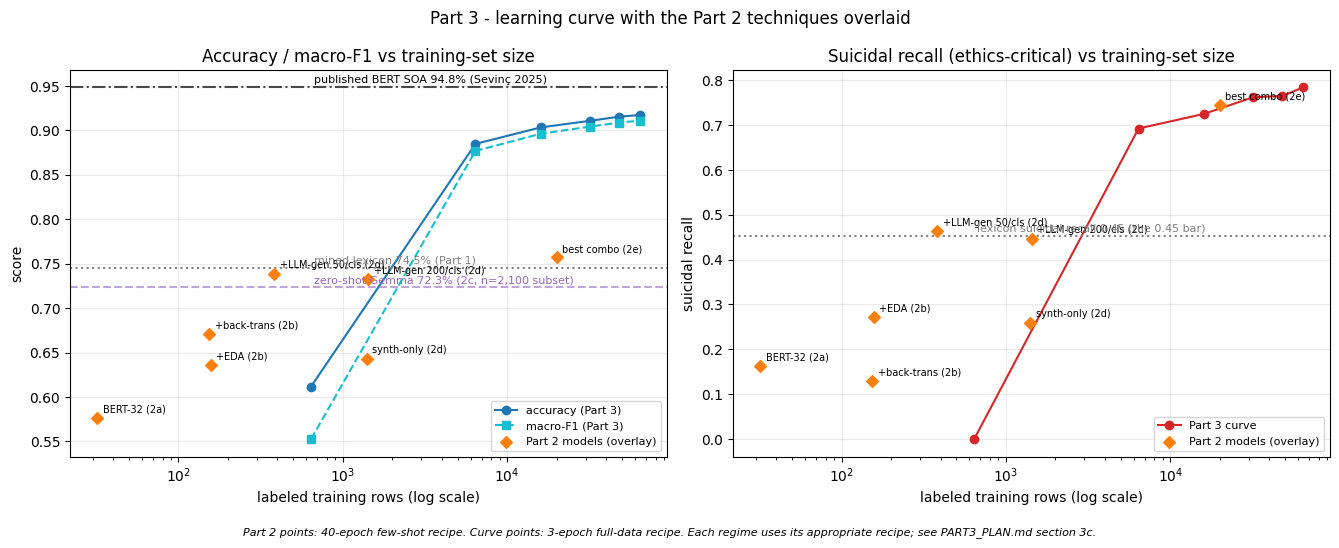

Saved part3_learning_curve (png+pdf).


In [ ]:
def load_metrics(name):
    p = METRICS_DIR / f'{name}.json'
    return json.loads(p.read_text()) if p.exists() else None

curve = []
for pct in FRACTIONS:
    m = load_metrics(pct_run_name(pct))
    if m:
        curve.append({'pct': pct, 'n': m['n_train_labels'], 'accuracy': m['accuracy'],
                      'macro_f1': m['macro_f1'],
                      'suicidal_recall': m['per_class']['suicidal']['recall']})

if not curve:
    print('No part3 metrics JSONs yet - run the 3a scoring cell first.')
else:
    cdf = pd.DataFrame(curve).sort_values('n')

    OVERLAY = {'part2_bert_32': 'BERT-32 (2a)',
               'part2_bert_backtrans': '+back-trans (2b)',
               'part2_bert_eda_160': '+EDA (2b)',
               'part2_bert_llmgen_50': '+LLM-gen 50/cls (2d)',
               'part2_bert_llmgen_200': '+LLM-gen 200/cls (2d)',
               'part2_bert_synth_only': 'synth-only (2d)',
               'part2_best_combo': 'best combo (2e)'}
    overlay = []
    for name, lbl in OVERLAY.items():
        m = load_metrics(name)
        if m:
            overlay.append({'label': lbl,
                            'n': m.get('n_train_effective', m.get('n_train_labels', m['n'])),
                            'accuracy': m['accuracy'],
                            'suicidal_recall': m['per_class']['suicidal']['recall']})
    lexicon = load_metrics('part1_rule_based_mined')
    zeroshot = load_metrics('part2_zero_shot_llm_n2100')

    soa = load_metrics('part0_soa_reference')
    plot_part3_learning_curve(cdf, overlay, lexicon, zeroshot, soa, fig_dir=FIG_DIR)

#### Learning Curve Visualization

The figure shows the same story visually. On a log scale for the number of labeled rows, accuracy and macro-F1 climb steeply up to about 10% of the data and then flatten, and `suicidal` recall (right panel) follows the same shape against the 0.45 bar from the Part 1 lexicon. The Part 2 models are placed on the curve at the number of real labeled rows each one is effectively worth, which is what makes the comparison in 3c concrete.

Two limits are worth stating:

1. The bootstrap confidence intervals are computed for each point but not drawn on the curve, so the flattening is a visual reading rather than a formal significance test.
2. Because the fractions are nested, each one a superset of the smaller ones, the points share data and are not independent draws, so the curve describes this one nested sequence rather than the average over many random subsets.

### 3c. Technique Comparison

In [ ]:
if RUN_TRAINING:
    SYNTH_PATH   = PROJECT_ROOT / 'data' / 'synthetic' / 'synthetic.parquet'
    DISTILL_PATH = PROJECT_ROOT / 'data' / 'synthetic_2e' / 'distill_mix.parquet'
    TRAIN32_PATH = PROJECT_ROOT / 'data' / 'processed' / 'train_32.parquet'

    THREEC_RUNS = [('synth', 1), ('synth', 10), ('synth', 100), ('distill', 1), ('distill', 10), ('distill', 100)]

    synth_df   = pd.read_parquet(SYNTH_PATH)[['text', 'status']]
    distill_df = pd.read_parquet(DISTILL_PATH)[['text', 'status']]
    gold32     = set(pd.read_parquet(TRAIN32_PATH)['text'])

    def build_stack(source, pct):
        real = fraction_dfs[pct][['text', 'status']]
        seen = set(real['text'])
        if source == 'synth':
            extra = synth_df[~synth_df['text'].isin(seen)]
        else:
            extra = distill_df[~distill_df['text'].isin(seen | gold32)]
        return pd.concat([real, extra], ignore_index=True), len(real), len(extra)

    summaries = []
    for source, pct in THREEC_RUNS:
        run_name = f'part3_{source}_stack_pct{pct}_seed{CANONICAL_SEED}'
        if (RAW_PRED_DIR / f'{run_name}.csv').exists():
            print(f'{run_name}: staged CSV exists - skipping.'); continue
        frame, n_real, n_extra = build_stack(source, pct)
        print(f'{run_name}: {n_real} real gold + {n_extra} {source} = {len(frame)} train rows')
        summaries.append(train_and_predict_full(frame, run_name, CANONICAL_SEED))

    if summaries:
        print(pd.DataFrame(summaries).drop(columns='loss_history').to_string(index=False))
else:
    print('RUN_TRAINING is False - the 3c stacks train on Colab. Skipping.')


part3_synth_stack_pct1_seed42: staged CSV exists - skipping.
part3_synth_stack_pct10_seed42: staged CSV exists - skipping.
part3_synth_stack_pct100_seed42: staged CSV exists - skipping.
part3_distill_stack_pct1_seed42: staged CSV exists - skipping.
part3_distill_stack_pct10_seed42: staged CSV exists - skipping.
part3_distill_stack_pct100_seed42: staged CSV exists - skipping.


part3_synth_stack_pct1
Accuracy: 0.7824  (95% CI 0.7770-0.7882)
Macro F1: 0.7715  (95% CI 0.7662-0.7772)
Cohen's kappa: 0.7454
Suicidal recall: 0.5274 - misses 47% of 2,116 suicidal test texts
Missed suicidal texts are classified as:
depression              673
normal                  253
bipolar                  27
personality disorder     20
anxiety                  16
stress                   11
part3_synth_stack_pct10
Accuracy: 0.8807  (95% CI 0.8765-0.8849)
Macro F1: 0.8730  (95% CI 0.8686-0.8772)
Cohen's kappa: 0.8605
Suicidal recall: 0.7306 - misses 27% of 2,116 suicidal test texts
Missed suicidal texts are classified as:
depression              451
normal                   97
anxiety                   9
bipolar                   8
stress                    4
personality disorder      1
part3_synth_stack_pct100
Accuracy: 0.9177  (95% CI 0.9139-0.9214)
Macro F1: 0.9115  (95% CI 0.9076-0.9153)
Cohen's kappa: 0.9038
Suicidal recall: 0.7864 - misses 21% of 2,116 suicidal test texts


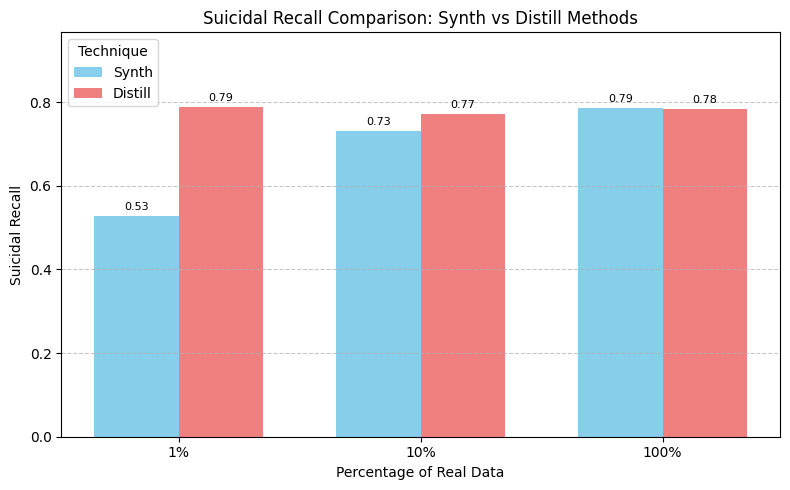

In [ ]:
THREEC_RUNS = [('synth', 1), ('synth', 10), ('synth', 100), ('distill', 1), ('distill', 10), ('distill', 100)]
threec_csv = lambda s, p: RAW_PRED_DIR / f'part3_{s}_stack_pct{p}_seed{CANONICAL_SEED}.csv'

missing = [threec_csv(s, p).name for s, p in THREEC_RUNS if not threec_csv(s, p).exists()]
if missing:
    print('3c stack-run CSVs still missing, run the 3c driver first (Colab).')
else:
    evaluate_model = make_evaluate_model(test_df=test_df, y_test=y_test, classes=classes,
                                         fig_dir=FIG_DIR, n_boot=N_BOOT, seed=SEED)
    rows = []
    for source, pct in THREEC_RUNS:
        name, path = f'part3_{source}_stack_pct{pct}', threec_csv(source, pct)
        sidecar = path.with_suffix('.json')
        run = json.loads(sidecar.read_text()) if sidecar.exists() else None
        preds = pd.read_csv(path, index_col='test_id')
        assert preds.index.equals(test_df.index), \
            f'{path.name} not aligned with the frozen test index - regenerate on Colab.'
        m = evaluate_model(name, preds['y_pred'].to_numpy(),
            title=None, make_figure=False,
            extras={'technique': source, 'fraction_pct': pct,
                    'n_real_labels': int(len(fraction_dfs[pct])),
                    'recipe': {'epochs': EPOCHS, 'train_batch': TRAIN_BATCH, 'lr': LR,
                               'warmup_frac': WARMUP_FRAC, 'max_length': MAX_LENGTH},
                    'canonical_seed': CANONICAL_SEED, 'single_seed_disclosed': True,
                    'seed_runs': {str(CANONICAL_SEED): run} if run else {}})
        rows.append({'run': name, 'technique': source, 'pct': pct,
                     'n_real': int(len(fraction_dfs[pct])), 'accuracy': m['accuracy'],
                     'macro_f1': m['macro_f1'], 'suicidal_recall': m['per_class']['suicidal']['recall']})
    print(pd.DataFrame(rows).set_index('run').round(4).to_string())

    plot_df = pd.DataFrame(rows)
    plot_df = plot_df.sort_values(by=['pct', 'technique'])

    plot_part3_synth_vs_distill_recall(plot_df)

#### Data Augmentation Techniques Comparison

The performance should be evaluated against the real-only baselines established in 3a: 1% alone scores 61.2% accuracy and 0.000 `suicidal` recall, 10% alone scores 88.5% and 0.692, and the full set (`pct100`) scores 91.7% and 0.784. The bar chart shows the `suicidal`-recall comparison directly, synthetic against teacher pseudo-labeling at each data size. Four findings stand out:

1. At 1%, both techniques rescue the collapsed point: synthetic reaches 78.2% accuracy and 0.527 `suicidal` recall, teacher pseudo-labeling reaches 79.8% accuracy and 0.788 `suicidal` recall.
2. The clearest result is on the ethics metric: teacher pseudo-labeling on just the 1% real fraction reaches 0.788 `suicidal` recall, the same as the full 64,069-row model (0.784). That needs a hedge: this run is still about 12 accuracy points worse overall (79.8% against 91.7%), and the matched figure is recall only, so it is catching `suicidal` posts partly by over-predicting that class rather than by being as good as the full-data model.
3. At 10% the accuracy benefit has gone (synthetic 88.1%, teacher pseudo-labeling 87.6%, both about the same as the 88.5% baseline) and only a small `suicidal`-recall edge remains (synthetic 0.731, teacher pseudo-labeling 0.770).
4. At the full dataset the techniques make essentially no difference: synthetic gives 91.8% accuracy and 0.786 `suicidal` recall, teacher pseudo-labeling gives 91.6% and 0.783, against the real-only `pct100` baseline of 91.7% and 0.784.

This matches the augmentation literature: extra data helps most when real labels are scarce and fades as real data grows. Once all the real labels are present, adding generated or teacher-labeled rows neither helps nor hurts.

### 3d. Methodology Analysis

In this stage of the project, we focused on progressively increasing the amount of training data to observe at what point the model's performance improved significantly. Unlike Part 2, where only 32 labeled examples were available, here we evaluated BERT using increasing portions of the complete dataset.

With only 1% of the training data, BERT already began approaching the performance of the models presented in the previous sections. Once the model was trained with 10% of the dataset, it clearly outperformed all previous approaches, reaching an accuracy of 88.5%. This suggests that BERT has a strong predictive capability and that its main limitation in Part 2 was not the model itself, but rather the extremely limited amount of labeled data available for fine-tuning. As the amount of training data continued to increase, the model kept improving, although the gains became progressively smaller. This reflects the typical diminishing returns observed in learning curves, where the largest improvements occur after the first increases in training data, while additional data continue to improve performance but at a slower rate.

We also evaluated the Stack models, which combine the best-performing techniques from Part 2 with progressively larger portions of the real dataset. These models incorporate strategies such as synthetic data generation and knowledge distillation together with a reduced percentage of real labeled data. The results show that, with only 1% of the real dataset, these techniques substantially improved performance, increasing the accuracy from 61.2% (BERT 1%) to 78.2%-79.8%. This is consistent with the conclusions obtained in Part 2, confirming that these techniques are particularly effective under low-resource conditions. However, once 10% of the real dataset became available, standard BERT achieved a performance that was equal to or slightly better than the Stack models. This indicates that the advantage provided by augmentation and distillation techniques rapidly decreases as more real labeled data become available.

Our main conclusion from this section, and from the project, is that the best-performing model was BERT trained with 100% of the dataset, achieving an accuracy of 91.7%, approaching the reported state-of-the-art (94.8%). This model also obtained the best performance across the other relevant metrics, including Macro F1 (91.1%) and Suicidal Recall (78.8%), outperforming the BERT models trained with smaller portions of the dataset.

Together with the findings from Parts 1 and 2, these results indicate that different methodologies are appropriate depending on data availability: rule-based methods provide strong and interpretable baselines, LLM-based techniques effectively compensate for scarce labeled data, and transformer models trained with sufficient real data achieve performance close to the state of the art.

## Teacher Model Selection for Part 4


In [ ]:
if RUN_TRAINING:
    SYNTH_PATH   = PROJECT_ROOT / 'data' / 'synthetic' / 'synthetic.parquet'
    DISTILL_PATH = PROJECT_ROOT / 'data' / 'synthetic_2e' / 'distill_mix.parquet'
    TRAIN32_PATH = PROJECT_ROOT / 'data' / 'processed' / 'train_32.parquet'

    val_df = splits['val']
    gold   = fraction_dfs[100][['text', 'status']]
    seen   = set(gold['text'])
    gold32 = set(pd.read_parquet(TRAIN32_PATH)['text'])

    synth_extra   = pd.read_parquet(SYNTH_PATH)[['text', 'status']]
    synth_extra   = synth_extra[~synth_extra['text'].isin(seen)]
    distill_extra = pd.read_parquet(DISTILL_PATH)[['text', 'status']]
    distill_extra = distill_extra[~distill_extra['text'].isin(seen | gold32)]

    candidates = {'pct100': gold,
                  'synth100': pd.concat([gold, synth_extra], ignore_index=True),
                  'distill100': pd.concat([gold, distill_extra], ignore_index=True)}

    for name, frame in candidates.items():
        for seed in SEEDS:
            run = f'part4_teacher_{name}_val_seed{seed}'
            if (RAW_PRED_DIR / f'{run}.csv').exists():
                print(f'{run}: staged - skipping.'); continue
            train_and_predict_full(frame, run, seed,
                save_checkpoint_as=(f'part4_teacher_{name}_model' if seed == CANONICAL_SEED else None),
                eval_df=val_df, eval_index_name='row_id')
else:
    print('RUN_TRAINING is False - the Part 4 teacher candidates train on Colab. Skipping.')


part4_teacher_pct100_val_seed42: staged - skipping.
part4_teacher_synth100_val_seed42: staged - skipping.
part4_teacher_distill100_val_seed42: staged - skipping.


In [ ]:
y_val = splits['val']['status'].to_numpy()
val_index = splits['val'].index
cands = ['pct100', 'synth100', 'distill100']
rows, canon = [], {}

for name in cands:
    accs, recs = [], []
    for seed in SEEDS:
        path = RAW_PRED_DIR / f'part4_teacher_{name}_val_seed{seed}.csv'
        pred = pd.read_csv(path, index_col='row_id').loc[val_index, 'y_pred'].to_numpy()
        m = evaluate_predictions(y_val, pred, classes)
        accs.append(m['accuracy'])
        recs.append(m['per_class']['suicidal']['recall'])
        if seed == CANONICAL_SEED:
            canon[name] = pred

    rows.append({'candidate': name, 'seeds': len(SEEDS), 'val_acc': float(np.mean(accs)),
                 'val_acc_std': float(np.std(accs)), 'val_suicidal_recall': float(np.mean(recs))})

print(pd.DataFrame(rows).set_index('candidate').round(4).to_string(), '\n')
for a, b in [('pct100', 'synth100'), ('pct100', 'distill100'), ('synth100', 'distill100')]:
    p = mcnemar_test(y_val, canon[a], canon[b])['p_value']
    print(f'  {a} vs {b} (val, seed {CANONICAL_SEED}): McNemar p = {p:.3f}')
best = max(rows, key=lambda r: r['val_acc'])['candidate']
print(f'\nHighest val accuracy: {best}.')

            seeds  val_acc  val_acc_std  val_suicidal_recall
candidate                                                   
pct100          1   0.9151          0.0               0.7620
synth100        1   0.9143          0.0               0.7750
distill100      1   0.9139          0.0               0.7555 

  pct100 vs synth100 (val, seed 42): McNemar p = 0.561
  pct100 vs distill100 (val, seed 42): McNemar p = 0.158
  synth100 vs distill100 (val, seed 42): McNemar p = 0.811

Highest val accuracy: pct100.
